In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving wholesale_customers.csv to wholesale_customers.csv


In [ ]:
df=pd.read_csv("wholesale_customers.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
X= df.drop(['Channel', 'Region'], axis=1)
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

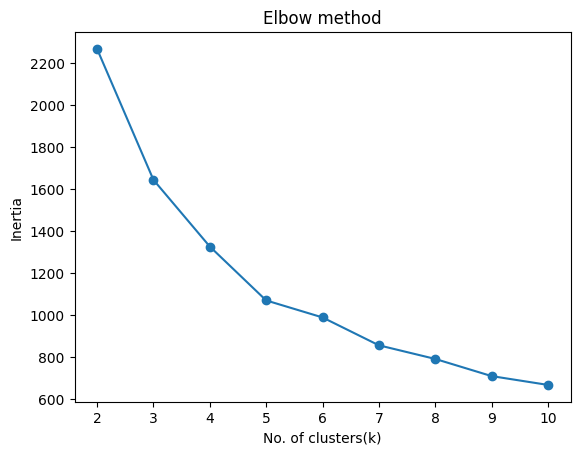

In [ ]:
inertia=[]
K=range(2, 11)
for k in K:
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.title('Elbow method')
plt.xlabel('No. of clusters(k)')
plt.ylabel('Inertia')
plt.show()

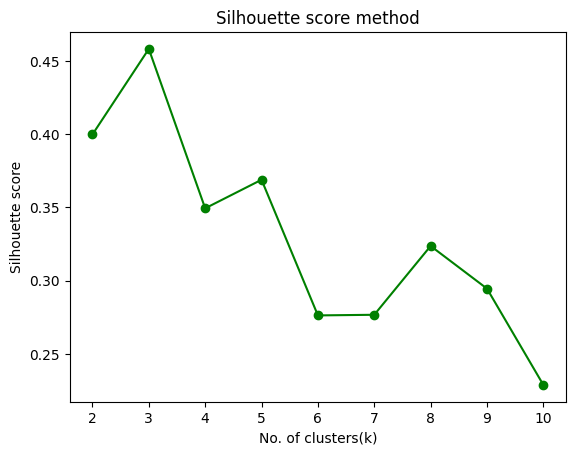

Optimal no of clusters based on silhouette score: 3


In [ ]:
silhouette_scores=[]
for k in range(2, 11):
    kmeans= KMeans(n_clusters=k, random_state=42)
    preds= kmeans.fit_predict(X_scaled)
    score= silhouette_score(X_scaled, preds)
    silhouette_scores.append(score)

plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette score method')
plt.xlabel('No. of clusters(k)')
plt.ylabel('Silhouette score')
plt.show()

best_k = range(2, 11)[np.argmax(silhouette_scores)]
print("Optimal no of clusters based on silhouette score:", best_k)

In [ ]:
kmeans= KMeans(n_clusters=best_k, random_state=42)
clusters= kmeans.fit_predict(X_scaled)
df['Cluster']=clusters

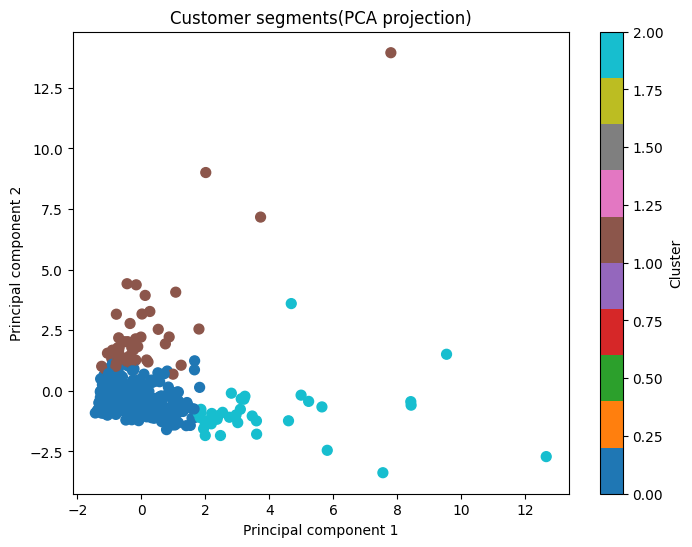

In [ ]:
pca= PCA(n_components=2)
pca_result= pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='tab10', s=50)
plt.title('Customer segments(PCA projection)')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
cluster_summary= df.groupby('Cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()
print("Cluster-wise Average Spending:\n", cluster_summary)

for i, row in cluster_summary.iterrows():
    if row.mean()>cluster_summary.mean().mean():
        print(f"Cluster {i}: High spenders")
    elif row.mean()<cluster_summary.mean().mean():
        print(f"Cluster {i}: Budget customers")
    else:
        print(f"Cluster {i}: Average customers")

Cluster-wise Average Spending:
                 Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0         8935.500000   4228.528571   5848.034286  2167.231429   
1        34540.113208   5860.358491   6122.622642  9841.735849   
2         8704.864865  20534.405405  30466.243243  1932.621622   

         Detergents_Paper   Delicassen  
Cluster                                 
0             1913.605714  1102.120000  
1              981.471698  3664.245283  
2            14758.837838  2459.351351  
Cluster 0: Budget customers
Cluster 1: High spenders
Cluster 2: High spenders
